In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import jaxfilter
from scipy import signal
import jax
import jax.numpy as jnp

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#e6edf3",
    "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3",
    "xtick.color": "#e6edf3",
    "ytick.color": "#e6edf3",
    "grid.color": "#2f3542",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#e6edf3",
    "font.size": 12,
})
COLOR_MAP = {
    "LMS": "#58a6ff",        # bright blue
    "NLMS": "#2dd4bf",       # cyan
    "APA (P=1)": "#f472b6",  # magenta
    "APA (P=2)": "#facc15",  # yellow
    "SignError": "#a3e635",  # lime
    "SignData": "#fb7185",   # red-pink
    "SignSign": "#c084fc",   # purple
    "DualSign": "#e879f9",
    "Pow2Err": "#fb923c",
}

In [2]:
from pathlib import Path
import jax
import jax.numpy as jnp
import flax.linen as nn
from typing import Optional, Union, Tuple, Dict, Any
# Force JAX to use float64 for better numerical agreement
jax.config.update("jax_enable_x64", True)

IMAGES_PATH = Path() / "images" / "doctest"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

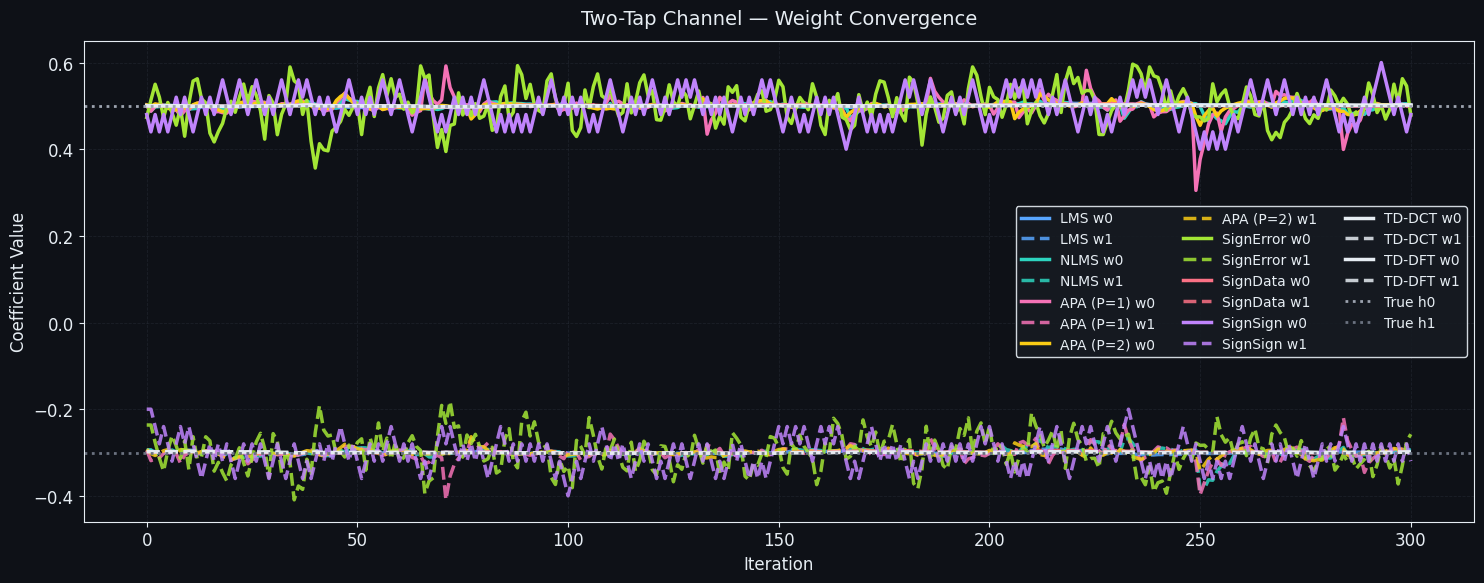

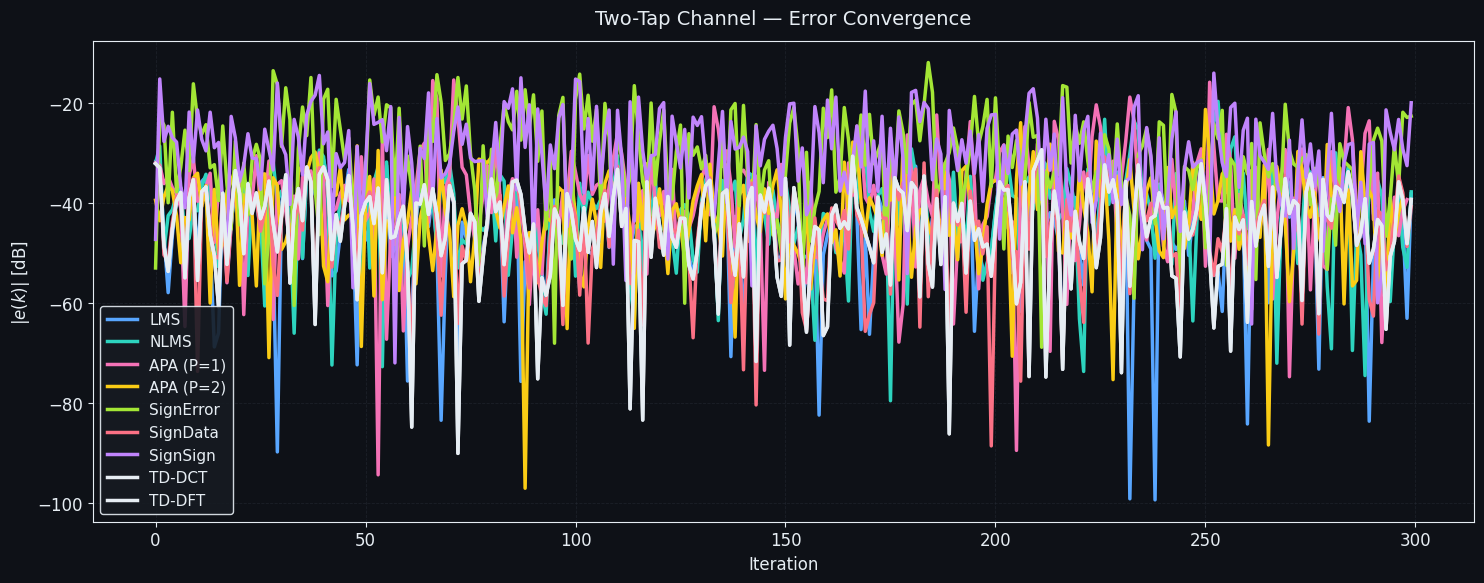

In [3]:
key = jax.random.PRNGKey(0)
key_x, key_n = jax.random.split(key)

N = 300
h = jnp.array([0.5 + 0j, -0.3 + 0j], dtype=jnp.complex64)

x = jax.random.normal(key_x, (N,), dtype=jnp.float32)

d = 0.5 * x + (-0.3) * jnp.concatenate(
    [jnp.array([0.0], x.dtype), x[:-1]]
)

d = d + 0.01 * jax.random.normal(key_n, (N,), dtype=jnp.float32)

# ------------------------------------------------------------
# 2. Instantiate all adaptive filters
# ------------------------------------------------------------
nlms_mu_n = 0.5

filters = {
    "LMS": jaxfilter.LMS(mu=0.05, filter_order=1),
    "NLMS": jaxfilter.NLMS(mu=nlms_mu_n, tau=1e-3, filter_order=1),
    "APA (P=1)": jaxfilter.AffineProjection(mu=0.5, P=1, delta=1e-3, filter_order=1),
    "APA (P=2)": jaxfilter.AffineProjection(mu=0.5, P=2, delta=1e-3, filter_order=1),
    "SignError": jaxfilter.SignErrorLMS(mu=0.02, filter_order=1),
    "SignData": jaxfilter.SignDataLMS(mu=0.02, filter_order=1),
    "SignSign": jaxfilter.SignSignLMS(mu=0.02, filter_order=1),
    "TD-DCT": jaxfilter.TransformDomain(mu=0.02, alpha=0.01, gamma=1e-8, matrix="dct", filter_order=1),
    "TD-DFT": jaxfilter.TransformDomain(mu=0.02, alpha=0.01, gamma=1e-8, matrix="dft", filter_order=1),
}

# Initialize variables (Flax requires init)
variables = {
    name: filt.init(key, x, d)
    for name, filt in filters.items()
}

# ------------------------------------------------------------
# 3. Run all adaptive filters
# ------------------------------------------------------------
results = {}
for name, filt in filters.items():
    (outputs, new_vars) = filt.apply(
        variables[name], x, d, train=True, mutable=["state"]
    )
    y, e, w_hist = outputs
    results[name] = (y, e, w_hist)

# ------------------------------------------------------------
# 4. Plot weight convergence
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

for name, (y, e, w_hist) in results.items():
    color = COLOR_MAP.get(name, "#e6edf3")

    plt.plot(
        jnp.real(w_hist[:, 0]),
        color=color,
        linewidth=2.5,
        label=f"{name} w0",
    )

    plt.plot(
        jnp.real(w_hist[:, 1]),
        color=color,
        linewidth=2.5,
        linestyle="--",
        alpha=0.85,
        label=f"{name} w1",
    )

# True coefficients (reference)
plt.axhline(0.5, color="#9ca3af", linestyle=":", linewidth=2, label="True h0")
plt.axhline(-0.3, color="#6b7280", linestyle=":", linewidth=2, label="True h1")

plt.title("Two-Tap Channel — Weight Convergence", fontsize=14, pad=12)
plt.xlabel("Iteration")
plt.ylabel("Coefficient Value")

plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
plt.legend(ncol=3, fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Plot error magnitude convergence
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

for name, (y, e, w_hist) in results.items():
    color = COLOR_MAP.get(name, "#e6edf3")

    plt.plot(
        20 * jnp.log10(jnp.abs(e) + 1e-12),
        color=color,
        linewidth=2.5,
        label=name,
    )

plt.title("Two-Tap Channel — Error Convergence", fontsize=14, pad=12)
plt.xlabel("Iteration")
plt.ylabel(r"$|e(k)|$ [dB]")

plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
plt.legend(fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()